## 1.	What is association rule mining?

⸻

Goal: find frequent “patterns” like:

People who buy A and B also tend to buy C

from a transactional database (e.g., supermarket receipts).

Example rule:

{Beer, Diapers} → {Milk}

Important: “→” means co-occurrence, NOT causality.  
It’s just: “in the data, these things appear together often”.  

Association rule mining is an exploratory technique:  
you don’t start with hypotheses; you let the patterns emerge.  

⸻

## 2.	Basic definitions

⸻

Transaction: one “basket” of items (e.g. one receipt).  

Item: a single product (Beer, Milk, Diapers, …).  

Itemset: a set of one or more items.  
Example: {Beer, Diapers}  

k-itemset: itemset containing k items.  
Example: {Beer, Diapers, Milk} is a 3-itemset.  

Support count (#): how many transactions contain that itemset.  
Example: #{Beer, Diapers} = 2 means there are 2 transactions that contain both Beer and Diapers.  

Support: fraction (or probability) of transactions that contain the itemset.  
sup({Beer, Diapers}) = #{Beer, Diapers} / |T|  
where |T| = number of transactions.  

Frequent itemset: itemset whose support is ≥ minsup (a minimum support threshold chosen by the user).  

⸻

## 3.	Support and confidence of a rule

⸻

A rule is:

A → B

where A and B are itemsets (they must be disjoint in practice, but conceptually both are itemsets).

Support of rule A → B:  

sup(A, B) = #{A ∪ B} / |T|  

i.e. fraction of transactions that contain both A and B.  
This is the rule frequency in the database.  

Confidence of rule A → B:  

conf(A → B) = sup(A, B) / sup(A)  

This is:  
- “given that A is present, how often is B also present?”  
- conditional probability P(B | A)  
- the “strength” of the arrow.  

We keep rules that satisfy:  

support ≥ minsup  
confidence ≥ minconf  


⸻

## 4.	Example of support and confidence

⸻

Suppose we have 5 transactions:  

T1: {Beer, Diapers, Milk}  
T2: {Beer, Diapers}  
T3: {Milk, Bread}  
T4: {Beer, Milk}  
T5: {Diapers, Bread}  

Itemset {Beer, Diapers} appears in T1 and T2:  
#{Beer, Diapers} = 2  
sup({Beer, Diapers}) = 2 / 5 = 0.4  

Rule: {Beer} → {Diapers}  

#{Beer, Diapers} = 2  
sup(Beer) = transactions with Beer = T1, T2, T4 = 3 → sup(Beer) = 3/5  

Support of rule = sup(Beer, Diapers) = 2/5 = 0.4  
Confidence = sup(Beer, Diapers) / sup(Beer) = (2/5) / (3/5) = 2/3 ≈ 0.67  


⸻

## 5.	Overall problem definition

⸻

Given a set of transactions T:  

“Association rule mining” = find all rules A → B such that:  
    sup(A, B) ≥ minsup  
    conf(A → B) ≥ minconf  

Naive brute-force plan:  
- Enumerate ALL possible rules (A → B) among all items.  
- Compute support and confidence for each.  
- Keep only those matching minsup and minconf.  

Problem: combinatorial explosion → computationally infeasible.  

So we split the problem in two steps:  

(1) Find all frequent itemsets (those with support ≥ minsup).  
(2) From each frequent itemset, generate rules that satisfy the confidence threshold.  

Example:  
Frequent itemset: {Milk, Diapers} with sup = 60%  
Possible rules:  
Milk → Diapers  
Diapers → Milk  
Then we compute confidence for each and keep the ones above minconf.  

⸻

## 6.	Frequent itemset generation (step 1)

⸻

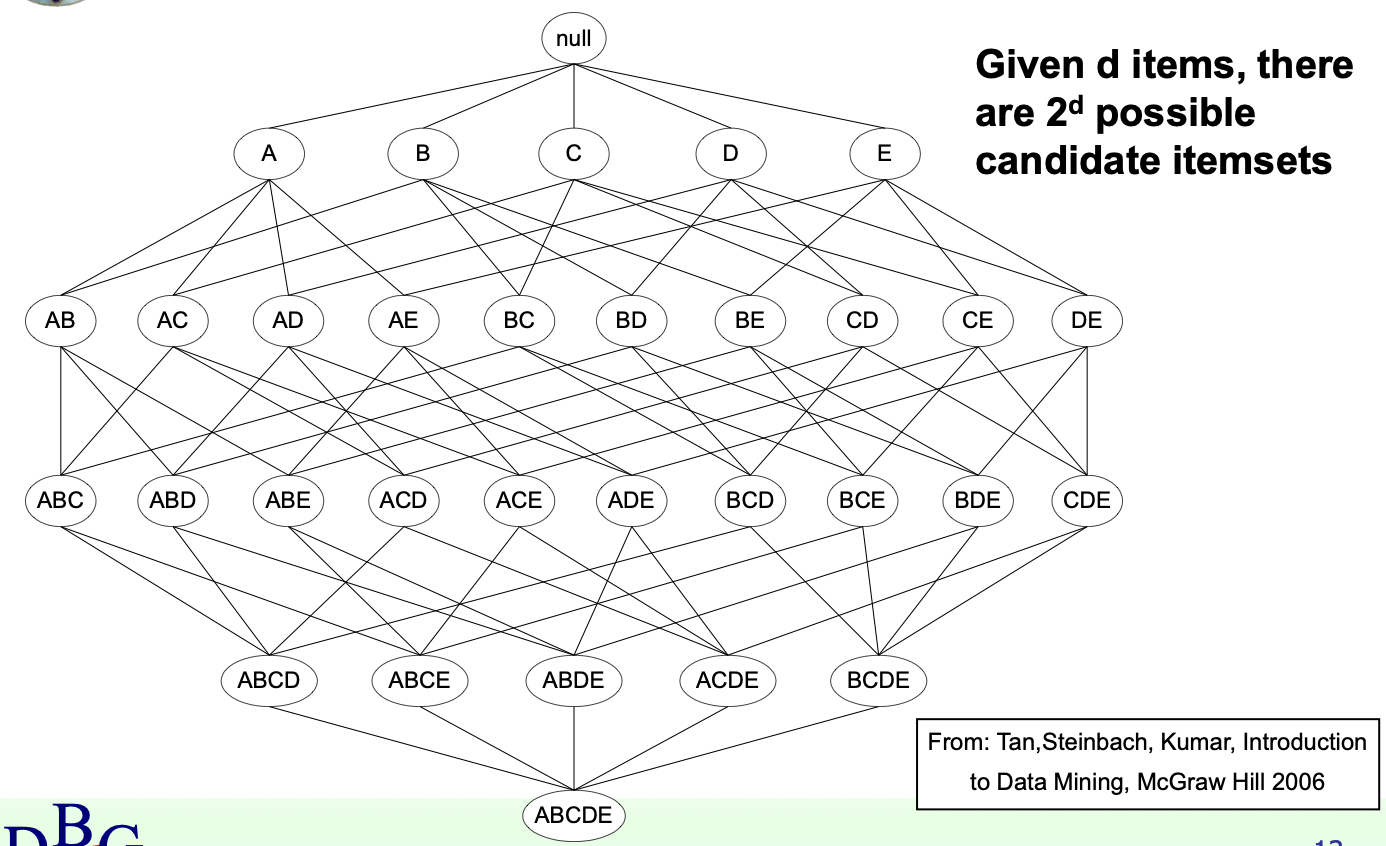

Given d items, there are 2^d possible itemsets (the power set).  
This can be seen as a lattice of all subsets.  

Brute-force frequent itemset generation:  
- treat every possible itemset as a candidate,
- scan the database to count support of each candidate,
- complexity ~ O(|T| * 2^d * w)  
|T| = number of transactions  
d   = number of items  
w   = average transaction length  

Too slow when d is not tiny.  

We want to improve efficiency by:  
- reducing number of candidates,
- reducing number of transactions considered,
- reducing number of comparisons (matches between transactions and candidates).

⸻

## 7.	The Apriori Principle

⸻

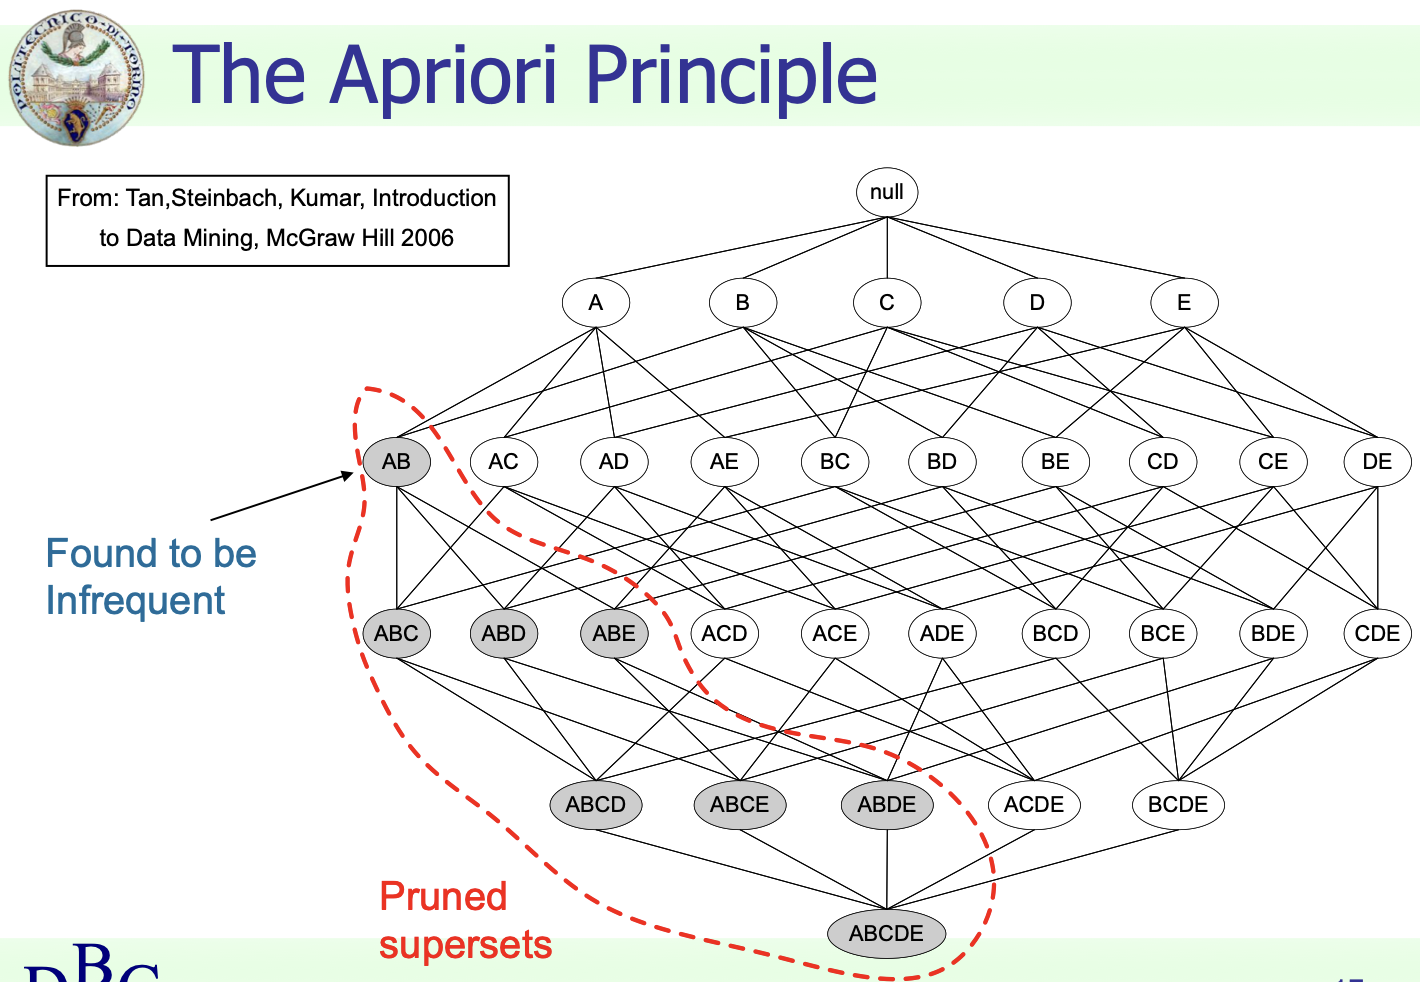


Core idea (antimonotonicity of support):  

If an itemset is frequent, all its subsets must also be frequent.  

Equivalent:  

If some subset of an itemset is NOT frequent,  
then the itemset itself CANNOT be frequent.  

Mathematically:  

If A ⊆ B, then sup(A) ≥ sup(B).  

Why it matters:  

We can prune the search space:  
- do not consider as candidates any itemset that has a subset known to be infrequent.  

This drastically cuts the number of candidates.  

⸻

## 8.	Apriori algorithm (high-level)

⸻

Level-wise (breadth-first) approach:  

At level k, we work with k-itemsets.  

For each level:  

(1) Candidate generation (from L_k to C_{k+1})  
- Join step:  
    - combine frequent k-itemsets to generate candidate (k+1)-itemsets  
- Prune step:  
    - use Apriori principle: if any k-subset of a (k+1)-candidate is not in L_k, then discard the candidate.  

(2) Frequent itemset generation  
    - scan database to count support of each candidate in C_{k+1}  
    - keep only those with support ≥ minsup → this set is L_{k+1}  

We start from L1 (frequent 1-itemsets) and go up until no more frequent itemsets can be found.  

⸻

## 9.	Example: candidate generation with Apriori

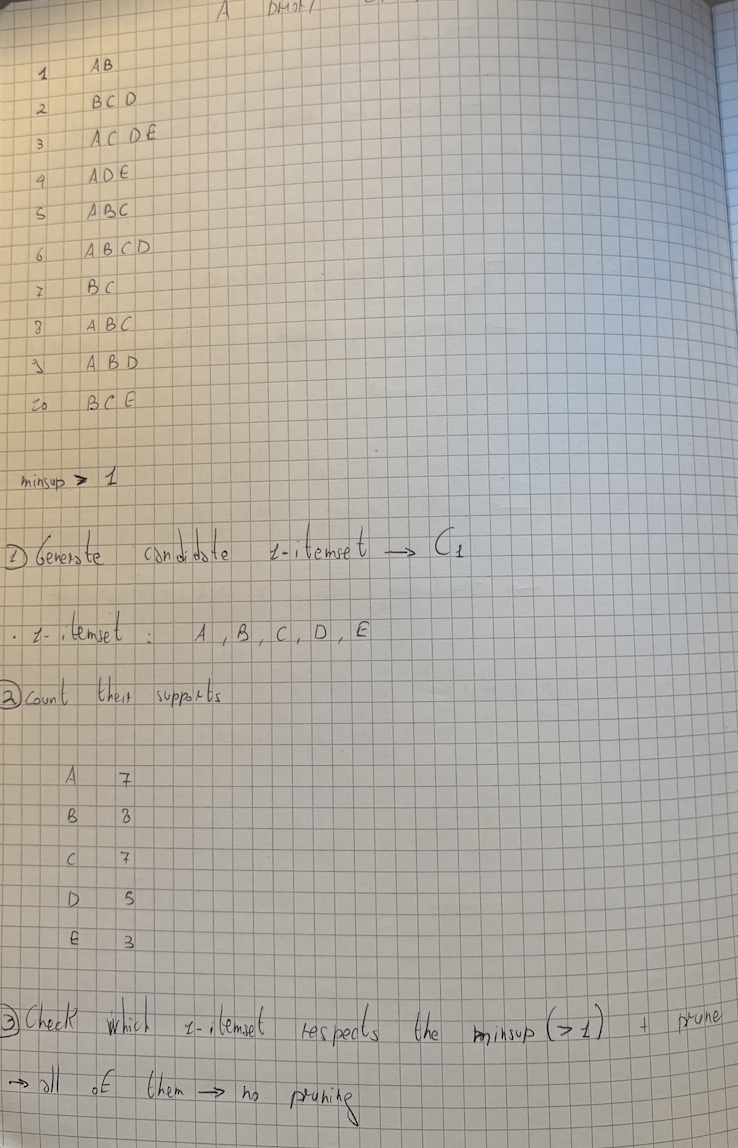

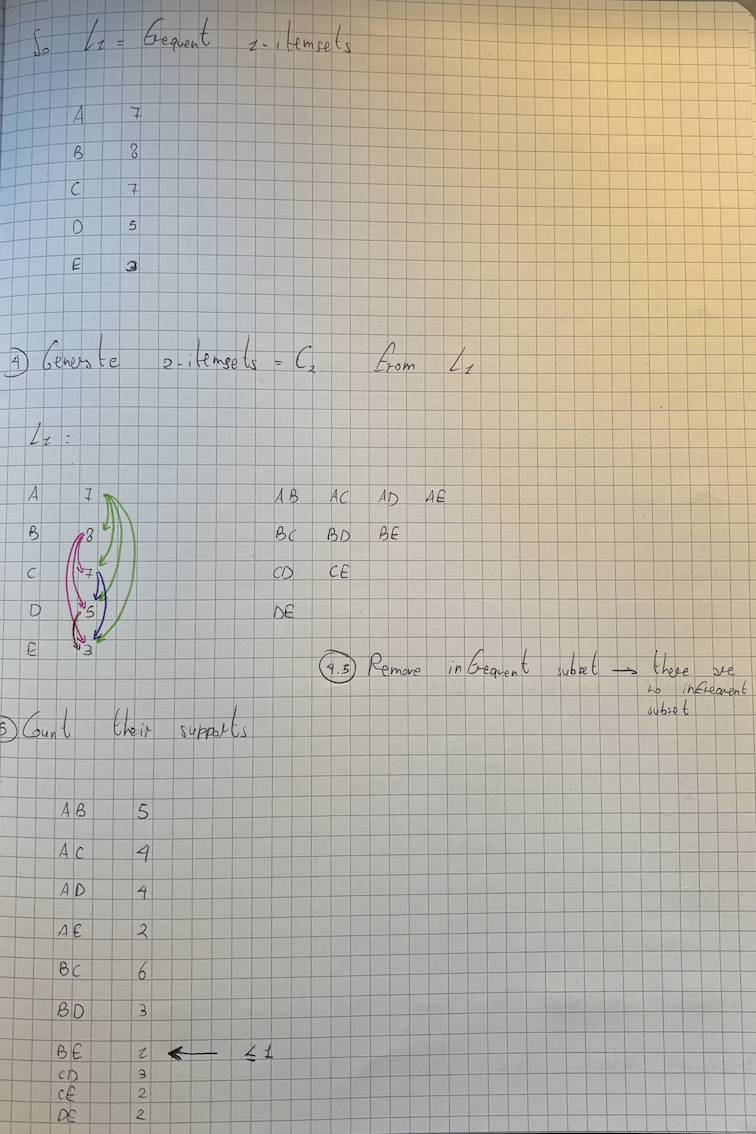

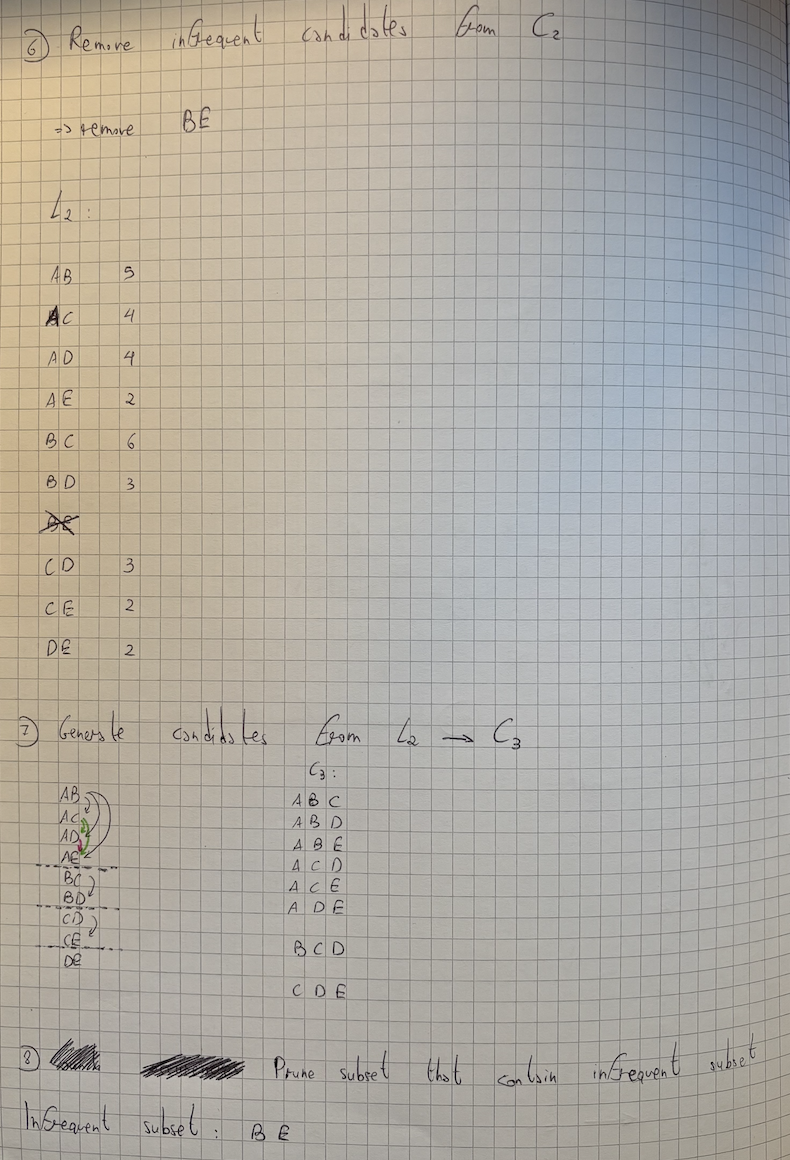

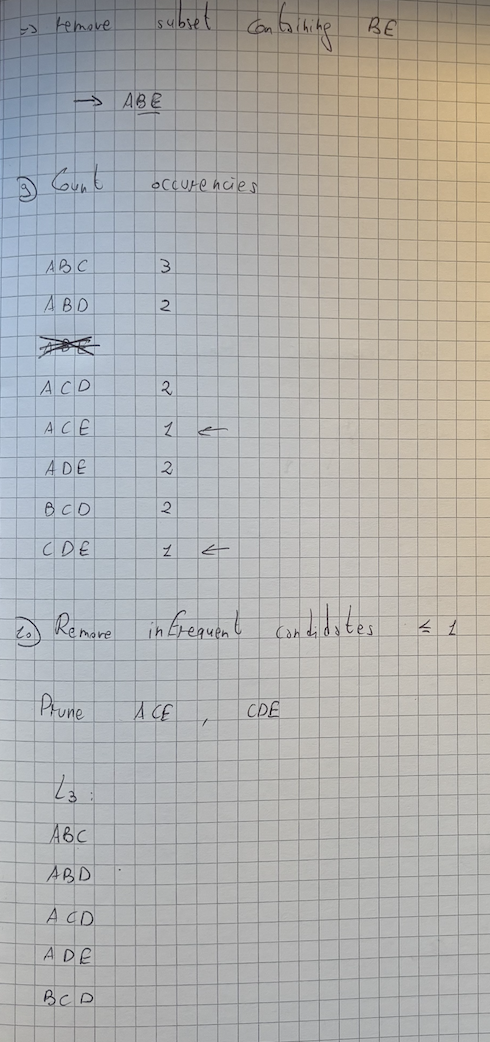

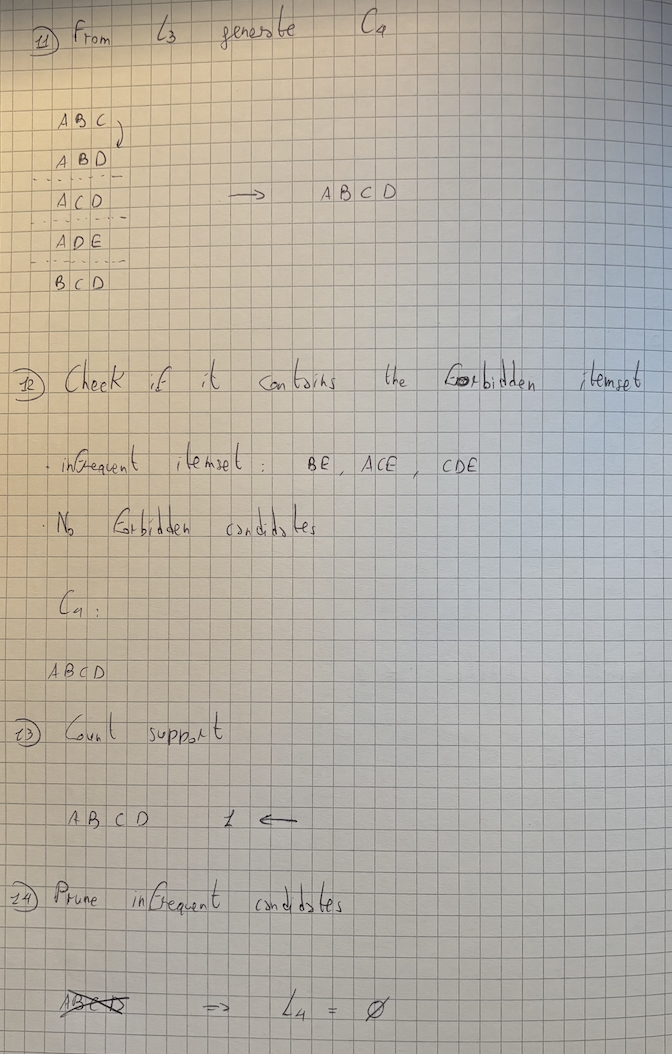

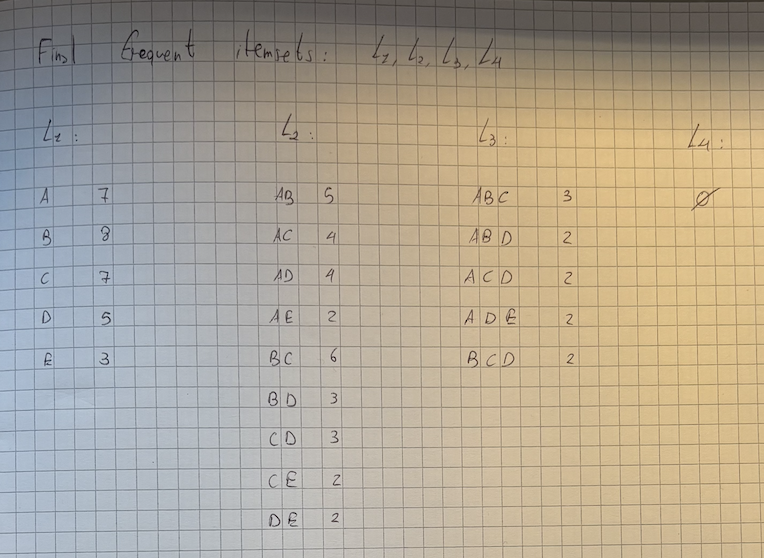

## 12.	Performance issues in Apriori

⸻

Main bottlenecks:  
	1.	Candidate generation:  
- candidate sets can be enormous,  
- especially C2 (2-itemsets) is critical,  
- long frequent itemsets require all frequent subsets to be found.  
	2.	Multiple database scans:  
- if the longest frequent itemset has length n,  
Apriori needs n+1 passes over the database (for L1, L2, …, Ln plus maybe initial).

⸻

## 13.	Factors affecting performance

⸻

Minimum support threshold:
- Lower minsup:
- more itemsets become “frequent”,
- more candidates,
- potentially longer frequent itemsets,
- more computational work.

Dimensionality (number of items d):
- more items:
- more possible itemsets,
- more memory to store counts,
- potentially more frequent items,
- more I/O and CPU.

Size of database (number of transactions |T|):
- more transactions:
- each scan is more expensive,
- Apriori needs multiple scans → total time grows.

Average transaction width (w: items per transaction):
- wider transactions (dense data):
- more subsets per transaction,
- longer potential frequent itemsets,
- more traversals of the hash-tree,
- more candidate matches per transaction.

⸻

## 14.	Techniques to improve Apriori efficiency

⸻

Hash-based itemset counting [Yu95]:
- use hashing to count candidate supports more efficiently.

Transaction reduction [Yu95]:
- remove transactions that cannot contain any frequent itemsets of future iterations
(e.g., if a transaction does not contain any frequent k-itemsets, it won’t help find frequent (k+1)-itemsets).

Partitioning [Sav96]:
- partition the database into chunks,
- find frequent itemsets locally,
- then combine results to get global frequent itemsets.

Sampling [Toi96]:
- use a random sample of the database to approximate frequent itemsets,
- then optionally verify on the full DB.

Dynamic Itemset Counting [Motw98]:
- change the way support is counted by inserting candidate itemsets dynamically as transactions are read,
- attempt to reduce the number of full passes over the data.

These are all optimizations to make Apriori (or Apriori-like) approaches less painful when data is large or dense.

Let’s turn that FP-growth chunk into a clear cheatsheet, same style as Apriori.

## 1.	Why FP-growth? (vs Apriori)

⸻

Apriori:
- generates tons of candidate itemsets,
- scans the DB many times (once per k),
- becomes very slow on large/dense data.

FP-growth:
- idea: compress the database once in memory as a tree (FP-tree),
- then mine frequent patterns from the tree itself, without generating huge candidate sets,
- needs only two scans of the database.

So FP-growth = “build a compact tree representation, then do recursive pattern mining on that tree”.

⸻

## 2.	What is an FP-tree?

⸻

FP-tree = “Frequent Pattern tree” = a compressed representation of the transaction DB.

Key points:
- Built from the frequent items only (items below minsup are discarded first).
- Items in each transaction are sorted by global frequency (most frequent first).
- Many transactions share prefixes (same first items) → these are stored as shared paths in the tree.
- Each node stores:
	- the item name,
	- a count (how many transactions go through this node).

Advantages:
- For dense data (many items per transaction, many overlaps), FP-tree can be very compressed.
- For sparse data, less compression, but still workable.
- It’s a complete representation for frequent pattern mining under the support constraint:
- no information is lost about which frequent patterns exist.

⸻

## 3.	High-level FP-growth process

⸻

Two main phases:

(1) Build the FP-tree  
(2) Mine frequent patterns from the FP-tree (FP-growth)  

Important: only two scans of the database:  
- Scan 1: count item supports, drop items below minsup.
- Scan 2: build the FP-tree by inserting all (filtered, ordered) transactions.

After that, all mining happens on the FP-tree, not on the original DB.

⸻

## 4.	FP-tree construction step-by-step

⸻

FP-tree construction:

(1) Count item support and prune items below minsup
- Scan the DB.
- Count support for each item.
- Remove infrequent items (support < minsup).
- Now you know which items are “frequent”.

(2) Build Header Table
- Take the frequent items.
- Sort them in decreasing support order (most frequent first).
- Put them in a “header table”:
- this is basically a list/array of items ordered by frequency.
- each header entry can also store a pointer to the first node in the FP-tree having that item (for later linking).

(3) Create the FP-tree
- Initialize the FP-tree with a root node (often labeled “null” or “∅”).
- For each transaction t in DB:
1. Filter t to keep only frequent items.  
2. Sort those items in the same order as the header table (decreasing global support).  
3. Insert this ordered list into the FP-tree:  
- Start from the root.
- For each item in the ordered transaction:
	- If a child node with that item already exists along the current path:
	- move to that child and increment its count (path is shared).
- Else:
	- create a new child node with count = 1,
	- link it in the FP-tree,
	- and connect it via the header structure (so all nodes of the same item are accessible via a linked list).

As a result:
- many transactions that share the same prefix share the same path in the tree,
- the counts along the path reflect how many transactions passed through.

⸻

## 5.	Intuition for FP-tree insertion

⸻

Example idea (not your full DB, just to visualize):

Suppose after filtering/sorting, we have transactions:

T1: [A, B, C]
T2: [A, B, D]
T3: [A, C]

Inserting into FP-tree:
- Insert T1: A → B → C as a new path from root; counts all 1.
- Insert T2:
	- from root: there is already a child A → increment A’s count,
	- from A: there is already a child B → increment B’s count,
	- from B: there is no child D → create node D with count 1.
- Insert T3:
	- from root: A exists → increment its count again,
	- from A: C child exists? (depending on previous insertions; if not, create; if yes, increment).

Result:
	•	root → A (count = 3)
	•	A → B (count = 2)
	•	B → C (count = 1)
	•	B → D (count = 1)
	•	A → C (maybe count = 1 if separate branch)

The tree is compact:
	•	instead of storing all transactions separately,
	•	we store shared prefixes with counts.

⸻

## 6.	Frequent pattern mining with FP-growth

⸻

Once the FP-tree is built, FP-growth does:
	•	recursively visit the FP-tree,
	•	uses a divide-and-conquer approach:
	•	picks an item,
	•	builds its “conditional pattern base” (all paths leading to that item),
	•	builds a smaller FP-tree from that,
	•	mines frequent patterns there,
	•	and so on.

Big picture:
	•	We avoid generating candidate itemsets like Apriori.
	•	We work with “conditional” FP-trees that shrink as we go deeper.
	•	Still respects the support threshold (minsup) in the recursive mining.

For the lab, what you mainly need to remember:
	•	FP-growth:
	•	compress DB into FP-tree,
	•	then recursively mine patterns from the tree.
	•	Key differences vs Apriori:
	•	no huge explicit candidate sets,
	•	no many database scans,
	•	good for large/dense datasets.

---

## Example DB

Example DB  
TID  Items  
1    {A,B}  
2    {B,C,D}  
3    {A,C,D,E}  
4    {A,D,E}  
5    {A,B,C}  
6    {A,B,C,D}  
7    {B,C}  
8    {A,B,C}  
9    {A,B,D}  
10   {B,C,E}  

minsup > 1  (so we keep itemsets that appear at least 2 times)

---

## 1. FP-TREE CONSTRUCTION

---

### 1.1 Header Table (after 1st DB scan)

Count support of each item and sort in decreasing support:

Header Table  
Item   sup  
{B}    8  
{A}    7  
{C}    7  
{D}    5  
{E}    3  

This defines the global order of items: B > A > C > D > E.  
Every transaction will be sorted according to this order before insertion.

---

### 1.2 Insert T1 into FP-tree

Original T1 = {A,B}  
Sorted by header order (B > A) → {B,A}

Sorted transaction  
TID      Items  
1        {B,A}

FP-tree

|—> B:1 —> A:1

Explanation:  
- Starting from the root, we create a child B with count 1.  
- From B, we create child A with count 1.

---

### 1.3 Insert T2 into FP-tree

Original T2 = {B,C,D}  
Already sorted by B > C > D → {B,C,D}

Sorted transaction  
TID  Items  
2    {B,C,D}

FP-tree

|—> B:2 —> A:1  
|  
|-> C:1 —> D:1  

Explanation:  
- The root already has child B:1 → increment to B:2.  
- Under B, there is no C yet on this branch → create C:1 → then D:1 under C.  
- The existing path B→A:1 is left unchanged.

---

### 1.4 Insert T3 into FP-tree

Original T3 = {A,C,D,E}  
Sorted by header order (B,A,C,D,E) → {A,C,D,E}  (no B in the transaction)

Sorted transaction  
TID  Items  
3    {A,C,D,E}

FP-tree

|—> B:2 —> A:1  
|	|  
|	|-> C:1 —> D:1  
|  
|—> A:1 —> C:1 —> D:1 —> E:1  

Explanation:  
- From root, there is no A child at root level yet → create a new branch A:1 → C:1 → D:1 → E:1.  
- The branch starting with B stays as it was.

---

### 1.5 Insert T4 into FP-tree

Original T4 = {A,D,E}  
Sorted by header order → {A,D,E}

Sorted transaction  
TID  Items  
4    {A,D,E}

FP-tree

|—> B:2 —> A:1  
|	|  
|	|—> C:1 —> D:1  
|  
|—> A:2 —> C:1 —> D:1 —> E:1  
|  
|—> D:1 —> E:1  

Explanation:  
- The root already has an A:1 branch → increment to A:2.  
- Under this A node, there is already a C:1 → D:1 → E:1 branch.  
- For T4 = {A,D,E}, after A we need D, not C, so from A we create a new child D:1 → E:1 (a second branch under A).

---

### 1.6 Insert T5 into FP-tree

Original T5 = {A,B,C}  
Sorted by header order B > A > C → {B,A,C}

Sorted transaction  
TID   Items  
5     {B,A,C}

FP-tree

|—> B:3 —> A:2 —> C:1  
|	|  
|	|—> C:1 —> D:1  
|  
|—> A:2 —> C:1 —> D:1 —> E:1  
|  
|—> D:1 —> E:1  

Explanation:  
- Root’s B:2 becomes B:3.  
- Under B, A:1 becomes A:2.  
- Under that A, we add a child C:1 (the path for this transaction), separate from the C:1 under B’s other child or other branches.

---

### 1.7 Insert T6 into FP-tree

Original T6 = {A,B,C,D}  
Sorted by header order → {B,A,C,D}

Sorted transaction  
TID   Items  
6     {B,A,C,D}

FP-tree

|—> B:4 —> A:3 —> C:2 —> D:1  
|	|  
|	|—> C:1 —> D:1  
|  
|—> A:2 —> C:1 —> D:1 —> E:1  
|  
|—> D:1 —> E:1  

Explanation:  
- B:3 → B:4.  
- Under B, A:2 → A:3.  
- Under that A, C:1 → C:2.  
- From that C, we add a D:1.

---

### 1.8 Insert T7 into FP-tree

Original T7 = {B,C}  
Sorted by header order → {B,C}

Sorted transaction  
TID   Items  
7     {B,C}

FP-tree

|—> B:5 —> A:3 —> C:2 —> D:1  
|	|  
|	|—> C:2 —> D:1  
|  
|—> A:2 —> C:1 —> D:1 —> E:1  
|  
|—> D:1 —> E:1  

Explanation:  
- B:4 → B:5.  
- Under B, this transaction’s next item is C (not A), so from B we add/extend a branch C:2 (its count becomes 2).

---

### 1.9 Insert T8 into FP-tree

Original T8 = {A,B,C}  
Sorted → {B,A,C}

Sorted transaction  
TID   Items  
8     {B,A,C}

FP-tree

|—> B:6 —> A:4 —> C:3 —> D:1  
|	|  
|	|—> C:2 —> D:1  
|  
|—> A:2 —> C:1 —> D:1 —> E:1  
|  
|—> D:1 —> E:1  

Explanation:  
- B:5 → B:6.  
- Under B, A:3 → A:4.  
- Under that A, C:2 → C:3.

---

### 1.10 Insert T9 into FP-tree

Original T9 = {A,B,D}  
Sorted → {B,A,D}

Sorted transaction  
TID   Items  
9     {B,A,D}

FP-tree

|—> B:7 —> A:5 —> C:3 —> D:1  
|	|			|  
|	|			|—> D:1  
|	|  
|	|—> C:2 —> D:1  
|  
|—> A:2 —> C:1 —> D:1 —> E:1  
|  
|—> D:1 —> E:1  

Explanation:  
- B:6 → B:7.  
- Under B, A:4 → A:5.  
- Under this A, we need D directly after A (for {B,A,D}). There is currently C:3 branch; so from A we add a new child D:1.

---

### 1.11 Insert T10 into FP-tree

Original T10 = {B,C,E}  
Sorted → {B,C,E}

Sorted transaction  
TID   Items  
10    {B,C,E}

FP-tree

|—> B:8 —> A:5 —> C:3 —> D:1  
|	|			|  
|	|			|—> D:1  
|	|  
|	|—> C:3 —> D:1  
|			|  
|			|—> E:1  
|  
|—> A:2 —> C:1 —> D:1 —> E:1  
|  
|—> D:1 —> E:1  

Explanation:  
- B:7 → B:8.  
- Under B, there is already a C branch with some count, which becomes C:3.  
- Under that C, we add E:1 (after possibly passing through D:1 depending on ordering in your drawing).

---

### 1.12 Final FP-tree

> This final FP-tree:

|—> B:8 —> A:5 —> C:3 —> D:1  
|	|			|  
|	|			|—> D:1  
|	|  
|	|—> C:3 —> D:1  
|			|  
|			|—> E:1  
|  
|—> A:2 —> C:1 —> D:1 —> E:1  
|  
|—> D:1 —> E:1  

is the “generic” FP-tree that summarizes the entire original DB under the given minsup.  
From now on, FP-growth will mine frequent patterns only from this tree, without scanning the original transactions again.

---

## 2. FP-GROWTH ALGORITHM (FOCUS ON ITEM D)

---

Goal:  
Use FP-growth on the FP-tree to extract all frequent itemsets that contain D (together with A, B, C) with minsup > 1.

General FP-growth idea (recap):  
- Scan header table from lowest support item upwards (in practice: E, then D, then C, then A, then B).  
- For each item i:  
  1. Build the i-Conditional Pattern Base (i-CPB) → collect all prefix-paths that end in item i.  
  2. From i-CPB, build the i-conditional FP-tree.  
  3. Recursively apply FP-growth on that conditional tree to find larger patterns that include i.

Here you chose to start with item D (even though E has lower support), because it’s a more interesting example.

---

### 2.1 Choose item D

We highlight item D in the header table:

Header Table  
Item      sup  
{B}       8  
{A}       7  
{C}       7  
{D}     5  
{E}       3  

And we look at the FP-tree (D nodes are marked):

FP-tree  
|—> B:8 —> A:5 —> C:3 —> D:1  
|	|			|  
|	|			|—> D:1  
|	|  
|	|—> C:3 —> D:1  
|			|  
|			|—> E:1  
|  
|—> A:2 —> C:1 —> D:1 —> E:1  
|  
|—> D:1 —> E:1  

We want all frequent itemsets that include D and possibly A, B, C.

---

### 2.2 Build D-CPB (D Conditional Pattern Base)

Step (1): select prefix-paths of item D from the FP-tree.  
Each D node with count 1 gives a path from the root up to the node just before D.

Your notes walk through highlighting the tree and incrementally listing prefixes:

FP-tree  
|—> B:8 —> A:5 —> C:3 —> D:1  
|	|			|  
|	|			|—> D:1  
|	|  
|	|—> C:3 —> D:1  
|			|  
|			|—> E:1  
|  
|—> A:2 —> C:1 —> D:1 —> E:1  
|  
|—> D:1 —> E:1  

Items    sup  
{B,A,C}  1  

(First prefix-path: B → A → C before a D.)

Then:

FP-tree  
|—> B:8 —> A:5 —> C:3 —> D:1  
|	|			|  
|	|			|—> D:1  
|	|  
|	|—> C:3 —> D:1  
|			|  
|			|—> E:1  
|  
|—> A:2 —> C:1 —> D:1 —> E:1  
|  
|—> D:1 —> E:1  

Items    sup  
{B,A,C}  1  
{B,A}    1  

(Second prefix-path: B → A before a different D.)

Next:

FP-tree  
|—> B:8 —> A:5 —> C:3 —> D:1  
|	|			|  
|	|			|—> D:1  
|	|  
|	|—> C:3 —> D:1  
|			|  
|			|—> E:1  
|  
|—> A:2 —> C:1 —> D:1 —> E:1  
|  
|—> D:1 —> E:1  

Items    sup  
{B,A,C}  1  
{B,A}    1  
{B,C}    1  

(Third prefix-path: B → C.)

Next:

FP-tree  
|—> B:8 —> A:5 —> C:3 —> D:1  
|	|			|  
|	|			|—> D:1  
|	|  
|	|—> C:3 —> D:1  
|		|  
|		|—> E:1  
|  
|—> A:2 —> C:1 —> D:1 —> E:1  
|  
|—> D:1 —> E:1  

Items    sup  
{B,A,C}  1  
{B,A}    1  
{B,C}    1  
{A,C}    1  

(4th prefix-path: A → C.)

Finally:

FP-tree  
|—> B:8 —> A:5 —> C:3 —> D:1  
|	|			|  
|	|			|—> D:1  
|	|  
|	|—> C:3 —> D:1  
|		|  
|		|—> E:1  
|  
|—> A:2 —> C:1 —> D:1 —> E:1  
|  
|—> D:1 —> E:1  

Prefix-paths of item D  
Items    sup  
{B,A,C}  1  
{B,A}    1  
{B,C}    1  
{A,C}    1  
{A}      1  

Now you summarize this as the D-CPB:

(1) Build D-CPB  
Select prefix-paths of item D from FP-tree

D-CPB  
Items    sup  
{B,A,C}  1  
{B,A}    1  
{B,C}    1  
{A, C}   1  
{A}      1  

And you note the simple frequent itemset:

Frequent itemset: D, sup(D) = 5

---

### 2.3 D-conditional Header Table

From D-CPB, compute conditional supports:

D-conditional Header Table  
Item   sup  
{A}    4  
{B}    3  
{C}    3  

This will be the item order in the D-conditional FP-tree: A > B > C.

---

### 2.4 Build the D-conditional FP-tree

We now “rebuild an FP-tree” only with the D-CPB transactions, using the order A > B > C.

D-CPB rows:

{B,A,C} 1  
{B,A}   1  
{B,C}   1  
{A,C}   1  
{A}     1  

Step-by-step, you insert each into the D-conditional FP-tree.  

1. Insert {B,A,C} with support 1  
Order according to A > B > C → {A,B,C},1  

Add it:

Items   sup  
{B,A,C} 1  

D-conditional FP-tree  
|  
|—> A:1 —> B:1 —> C:1  

2. Insert {B,A} with support 1  
Order → {A,B},1  

D-conditional FP-tree  
|  
|—> A:2 —> B:2 —> C:1  

(Count of A and B updated.)

3. Insert {B,C} with support 1  
Already ordered as {B,C}

D-conditional FP-tree  
|  
|—> A:2 —> B:2 —> C:1  
|  
|—> B:1 —> C:1  

(Second branch from root: B:1 → C:1.)

4. Insert {A,C} with support 1

D-conditional FP-tree  
|  
|—> A:3 —> B:2 —> C:1  
|	|  
|	|—> C:1  
|  
|—> B:1 —> C:1  

(Under A, we now also have a child C:1.)

5. Insert {A} with support 1

D-conditional FP-tree  
|  
|—> A:4 —> B:2 —> C:1  
|	|  
|	|—> C:1  
|  
|—> B:1 —> C:1  

This matches the final D-conditional FP-tree you wrote:

D-conditional FP-tree  
|  
|—> A:4 —> B:2 —> C:1  
|	|  
|	|—> C:1  
|  
|—> B:1 —> C:1  

---

### 2.5 Mining patterns that include D (via D-conditional tree)

Now FP-growth says:  
From the D-conditional FP-tree, we explore items in increasing support (often reversed header order).  
Here the D-conditional header table is:

Item   sup  
{A}    4  
{B}    3  
{C}    3  

You proceed (in your notes) by first picking C to build patterns that include D and C (i.e., “DC…”).

---

#### 2.5.1 Build DC-CPB (prefix paths of C in the D-conditional tree)

You select prefix-paths of C from the D-conditional FP-tree:

Build DC-CPB  
Select prefix-paths of item C (last one in the D-conditional header table) from D-conditional FP-tree → pick C → we are considering “DC”.

For each C node, you trace back up to (but excluding) C:

Frequent itemset: DC, sup(DC) = 3

D-conditional FP-tree  
|  
|—> A:4 —> B:2 —> C:1  
|	|  
|	|—> C:1  
|  
|—> B:1 —> C:1  

From this you list:

DC-CPB  
{A,B}  1  

(Derived from A → B → C path.)

Then:

D-conditional FP-tree  
|  
|—> A:4 —> B:2 —> C:1  
|	|  
|	|—> C:1  
|  
|—> B:1 —> C:1  

DC-CPB  
{A,B}  1  
{A}    1  

(From A → C path.)

Next:

D-conditional FP-tree  
|  
|—> A:4 —> B:2 —> C:1  
|	|  
|	|—> C:1  
|  
|—> B:1 —> C:1  

DC-CPB  
{A,B}  1  
{A}    1  
{B}    1  

This is your full DC-CPB.

Now you summarize:

(1) Build DC-CPB  
Select prefix-paths of item C from D-conditional FP-tree

DC-CPB  
{A,B}  1  
{A}    1  
{B}    1  

From DC-CPB, you obtain the DC-conditional Header Table:

DC-conditional Header Table  
{A} : 2  
{B} : 2  

---

#### 2.5.2 Build DC-conditional FP-tree

You build a small FP-tree from DC-CPB:

(2) Recursive invocation of FP-growth on DC-CPB  
Build tree from:

{A,B}  1  
{A}    1  
{B}    1  

DC-conditional FP-tree  
|  
|—>A:2 —> B:1  
|  
|—> B:1  

So this tree encodes patterns that include D and C, with possible A and B.

---

#### 2.5.3 Mine patterns from DC-conditional tree: DCB and DCA

Now you look at the DC-conditional Header Table:

From:  
DC-conditional Header Table:  
{A} : 2  
{B} : 2  

First, you select B to build patterns containing D, C, B:

Frequent itemset: DCB, sup(DCB) = 2

DC-conditional FP-tree  
|  
|—> A:2 —> B:1  
|  
|—> B:1 (no prefixes)

DCB-CPB  
{A}  1  

(1) Build DCB-CPB  
Select prefix-paths of item B from DC-conditional FP-tree → we pick B, so we are considering DCB.

DCB-CPB  
{A}  1  

Item A is infrequent in DCB-CPB (given minsup > 1), so:

A is removed from DCB-CPB  
DCB-CPB is empty  

(2) The search backtracks to DC-CPB.

Then, from DC-CPB, we consider item A:

(1) Build DCA-CPB  
Select prefix-paths of item A from DC-conditional FP-tree

Go back here:  
DC-CPB  
{A,B}  1  
{A}    1  
{B}    1  

DC-conditional Header Table:  
{A} : 2  
{B} : 2  

We now consider A, not B.  
Find the prefixes of A:

Frequent itemset: DCA, sup(DCA) = 2

DC-conditional FP-tree  
|  
|—>A:2 —> B:1  
|  
|—> B:1  

No prefixes (A is at the root under the DC-conditional tree), so:

DCA-CPB is empty (no transactions)

(2) The search backtracks to D-CPB.

---

#### 2.5.4 Back to D-CPB: consider item B (→ DB)

We now go back to D-CPB and consider B as the suffix extension:

(1) Build DB-CPB  
Select prefix-paths of item B from D-conditional FP-tree

Go back here:  
D-conditional Header Table  
Item    sup  
{A}     4  
{B}   3  
{C}     3  

We select B:

Frequent itemset: DB, sup(DB) = 3

D-conditional FP-tree  
|  
|—> A:4 —> B:2 —> C:1  
|	|  
|	|—> C:1  
|  
|—> B:1 —> C:1  

DB-CPB  
Items  sup  
{A}    2  

(You even note: “HUH??? THIS IS NOT TRUE, THAT’S WRONG DUDE?? THE SUPPORT SHOULD BE 1…..  
Facciamo finta di nulla”.)

Prefix of B:

DB-CPB  
Items  sup  
{A}    2  

DB-conditional Header Table  
Items  sup  
{A}    2  

Build the tree:

DB-conditional FP-tree  
|  
|—> A:2  

Frequent itemset: DBA, sup(DBA) = 2

(2) Recursive invocation of FP-growth on DB-CPB

(1) Build DBA-CPB  
Select prefix-paths of item A from DB-conditional FP-tree

DB-conditional FP-tree  
|  
|—> A:2  

Frequent itemset: DBA, sup(DBA) = 2

There are no prefix-paths of item A (A is at the root here), so:  
DBA-CPB is empty (no transactions)

(2) The search backtracks to D-CPB.

---

#### 2.5.5 Back to D-CPB: consider item A (→ DA)

Now we go back and consider item A from D-CPB:

D-conditional Header Table  
Item   sup  
{A}  4  
{B}    3  
{C}    3  

(1) Build DA-CPB  
Select prefix-paths of item A from D-conditional FP-tree

D-conditional FP-tree  
|  
|—> A:4 —> B:2 —> C:1  
|	|  
|	|—> C:1  
|  
|—> B:1 —> C:1  

Frequent itemset: DA, sup(DA) = 4

DA-CPB is empty  
(no transactions)

The search ends for item D.

---

### 2.6 Summary: Frequent itemsets including D

From this whole recursive process (starting from D), the frequent itemsets including D (and supported combinations of A, B, C) are summarized as:

TID  
Items  
1		{A,B}  
2		{B,C, D}  
3		{A,C, D,E}  
4		{A,D,E}  
5		{A,B,C}  
6		{A,B, C,D}  
7		{B,C}  
8		{A,B,C}  
9		{A,B,D}  
10		{B,C,E}  

minsup > 1  

itemsets	sup  
{D}		5  
{A, D}	4  
{B,D}	3  
{C,D}	3  
{A, B,D}	2  
{A, C,D}	2  
{B,C,D}	2  

So, structurally:  
- D alone is frequent.  
- D with each of A, B, C is frequent.  
- All 3-item combinations {D, A, B}, {D, A, C}, {D, B, C} are frequent (with support 2).

The above is exactly what FP-growth finds when starting from item D and recursively mining its conditional FP-trees.

---

## Frequent Maximal Itemsets (and example)

An itemset is frequent maximal if none of its immediate supersets
is frequent

- Frequent itemset = appears often enough (sup ≥ minsup).  
- Maximal frequent itemset = frequent, and if you try to add any extra item to it, the new bigger set is not frequent.

frequent maximal = frequent and if you add another letter it’s not frequent anymore, BIGGEST GROUP OF LETTERS WHILE STILL BEING FREQUENT, THERE ISN’T ANYTHING BIGGER THAN THAT THAT IS IS STILL FREQUENT.

### EXAMPLE

Transactions (TID → items):  
- T1: {A, B, C}  
- T2: {A, B}  
- T3: {A, C}  
- T4: {A, B, C}  
- T5: {B, C}  

Let minsup = 2 (an itemset is frequent if it appears in at least 2 transactions).

#### Step 1: supports

Single items:  
- sup({A}) = 4 (T1, T2, T3, T4)  
- sup({B}) = 4 (T1, T2, T4, T5)  
- sup({C}) = 4 (T1, T3, T4, T5)

All frequent.

Pairs:  
- sup({A,B}) = 3 (T1, T2, T4)  
- sup({A,C}) = 3 (T1, T3, T4)  
- sup({B,C}) = 3 (T1, T4, T5)

Triple:  
- sup({A,B,C}) = 2 (T1, T4) → frequent.

No larger sets exist (we only have items A,B,C).

#### Step 2: which are maximal?

Check {A,B,C}:  
- Is it frequent? Yes, sup = 2 ≥ minsup.  
- Can I add another item to it? No, there are no other items (A,B,C are all we have).  
- So none of its supersets is frequent (actually none exist),  
→ {A,B,C} is a frequent maximal itemset.

Check {A,B}:  
- Is it frequent? Yes (sup = 3).  
- Does it have a frequent superset?  
  Yes: {A,B,C} is a superset and is frequent (sup = 2).  
- So {A,B} is frequent, but not maximal.

- Frequent itemset: appears often enough.  
- Frequent maximal itemset:  
  “Frequent, and you can’t stick any other item on it and stay frequent.”

---

## Maximal vs Closed Itemsets

### EXAMPLE

Transactions:  
- T1: {A, B, C}  
- T2: {A, B}  
- T3: {A, B, C}  
- T4: {A, B, D}

Let minsup = 2.

#### Step 1 – supports

Single items:  
- sup({A}) = 4 (appears in T1,T2,T3,T4)  
- sup({B}) = 4  
- sup({C}) = 2 (T1,T3)  
- sup({D}) = 1 (T4 → infrequent)

Pairs:  
- sup({A,B}) = 4 (T1,T2,T3,T4)  
- sup({A,C}) = 2 (T1,T3)  
- sup({B,C}) = 2 (T1,T3)

Triple:  
- sup({A,B,C}) = 2 (T1,T3)

Frequent itemsets (sup ≥ 2):

{A}, {B}, {C}, {A,B}, {A,C}, {B,C}, {A,B,C}

---

### Closed vs Maximal (on this example)

Definitions (super dumb version):  
- Frequent: appears often enough.  
- Closed frequent: frequent and you can’t add items without changing the support  
  (no superset with the same support).  
- Maximal frequent: frequent and you can’t add items without becoming infrequent  
  (no frequent superset).

#### Closed frequent itemsets

Check each frequent itemset.  

- {A}, sup = 4  
  - Supersets: {A,B} (4), {A,C} (2), {A,B,C} (2)…  
  - There is a superset {A,B} with same support 4 → NOT closed.  

- {B}, sup = 4  
  - Superset {A,B} has support 4 → NOT closed.  

- {C}, sup = 2  
  - Supersets {A,C}, {B,C}, {A,B,C} all have support 2 → NOT closed.  

- {A,B}, sup = 4  
  - Supersets that are frequent: {A,B,C} (2). Support is different (2 ≠ 4).  
  - No superset with the same support → CLOSED.  

- {A,C}, sup = 2  
  - Superset {A,B,C} has support 2 → same support → NOT closed.  

- {B,C}, sup = 2  
  - Superset {A,B,C} has support 2 → NOT closed.  

- {A,B,C}, sup = 2  
  - No superset exists → CLOSED.

So:

Closed frequent itemsets = {A,B}, {A,B,C}

---

### Maximal frequent itemsets

- {A} has frequent supersets ({A,B}, {A,C}, {A,B,C}) → NOT maximal.  
- Same story for {B}, {C}, {A,B}, {A,C}, {B,C}.  
- {A,B,C} has no frequent superset → MAXIMAL.

So:

Maximal frequent itemsets = {A,B,C}

Note the relationship:  
- {A,B} is closed but not maximal (it has a frequent superset {A,B,C} with lower support).  
- {A,B,C} is closed and maximal.  
- {A}, {B}, {C}, {A,C}, {B,C} are frequent but not closed.